In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib import animation
import bottleneck as bn
import sunpy
import sunpy.map
import h5py
from astropy.time import Time
from astropy.io import ascii, fits
from astropy.wcs import WCS
from astropy.visualization import (ImageNormalize, 
                    SqrtStretch, AsinhStretch)
import astropy.units as u
from glob import glob 
from sunkit_image.enhance import wow

In [2]:
map_files = sorted(glob("../../data/20241015/hri_coalign/*.fits"))

In [3]:
hri_maps = sunpy.map.Map(map_files, sequence=True)

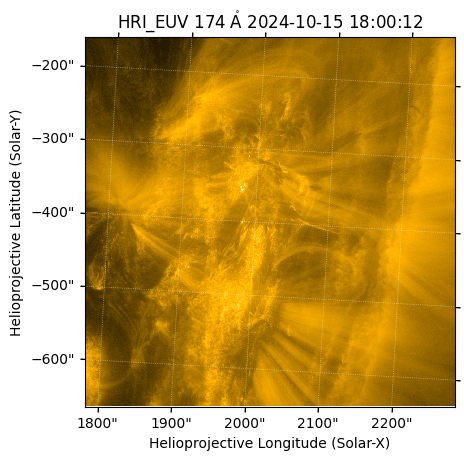

In [4]:
hri_maps[0].plot()

In [5]:
test_map = hri_maps[180]

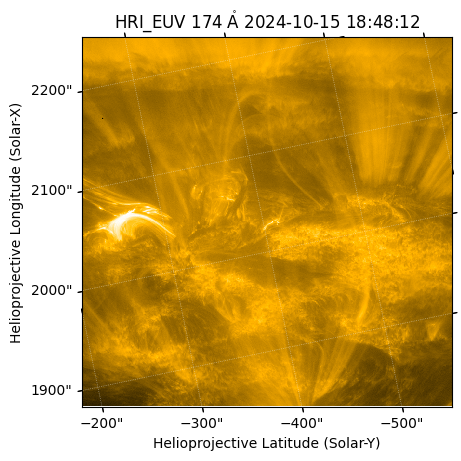

In [6]:
test_map = test_map.rotate(105*u.deg).submap(bottom_left=(256,256)*u.pix,
                                  top_right=(256+512+256-1, 256+512+256-1)*u.pix)
test_map.plot()

In [7]:
test_map_wow = wow(test_map.submap(bottom_left=(256, 128)*u.pix,
                   top_right=(256+512-1, 128+512-1)*u.pix),
                   bilateral=1, denoise_coefficients=[5,3,1], gamma=3.2, h=0.95)

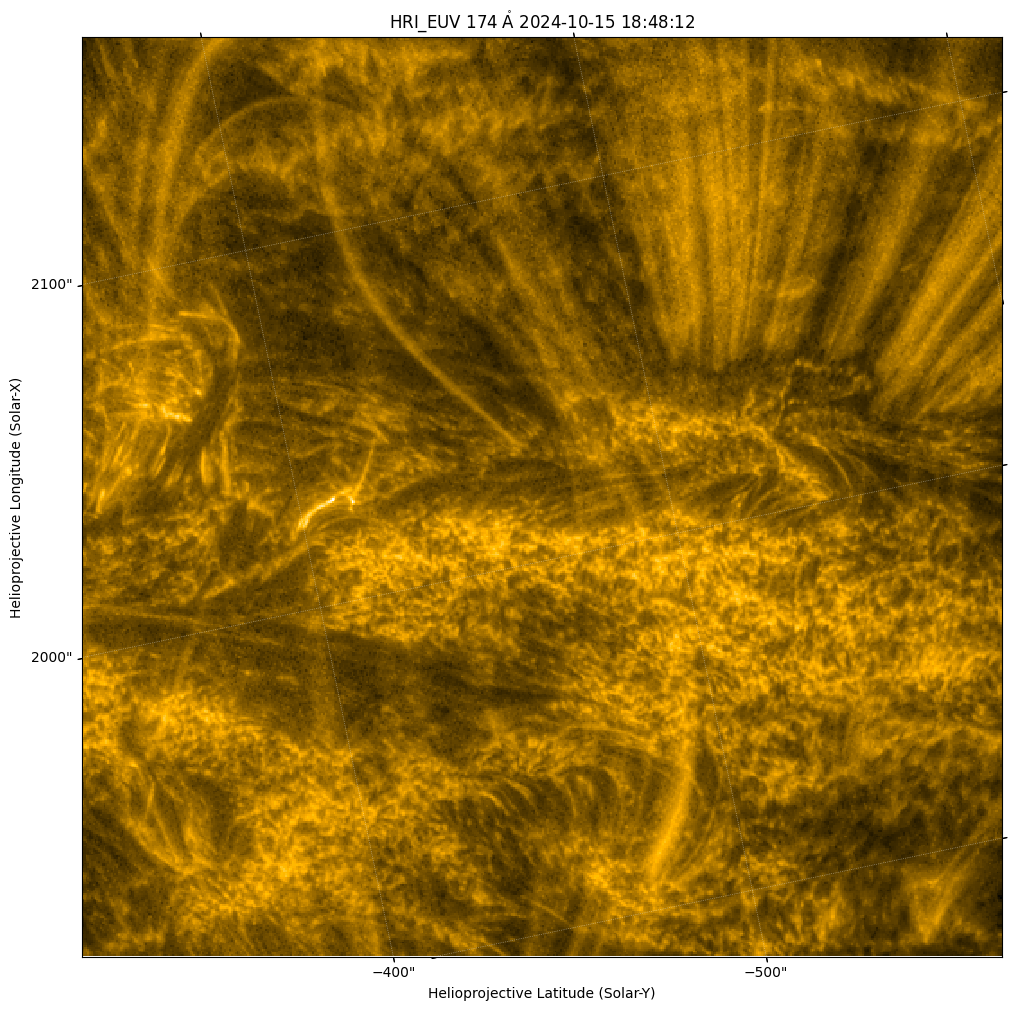

In [8]:
%matplotlib inline
fig = plt.figure(figsize=(10,10), layout="constrained")
ax = fig.add_subplot(projection=test_map_wow)
test_map_wow.plot(norm=ImageNormalize(), axes=ax)

In [9]:
hri_maps_array = hri_maps.data

In [10]:
hri_maps_array.shape

(1024, 1024, 1012)

In [11]:
hri_maps_array_mean_boxcar = bn.move_mean(hri_maps_array,window=3,axis=2,min_count=1)

In [12]:
test_map_boxcar = sunpy.map.Map(hri_maps_array_mean_boxcar[:,:,180], hri_maps[180].meta)
test_map_boxcar = test_map_boxcar.rotate(105*u.deg).submap(bottom_left=(256,256)*u.pix,
                                  top_right=(256+512+256-1, 256+512+256-1)*u.pix)

In [13]:
test_map_boxcar_wow = wow(test_map_boxcar.submap(bottom_left=(256, 128)*u.pix,
                   top_right=(256+512-1, 128+512-1)*u.pix),
                   bilateral=1, denoise_coefficients=[5,3,1], gamma=3.2, h=0.95)

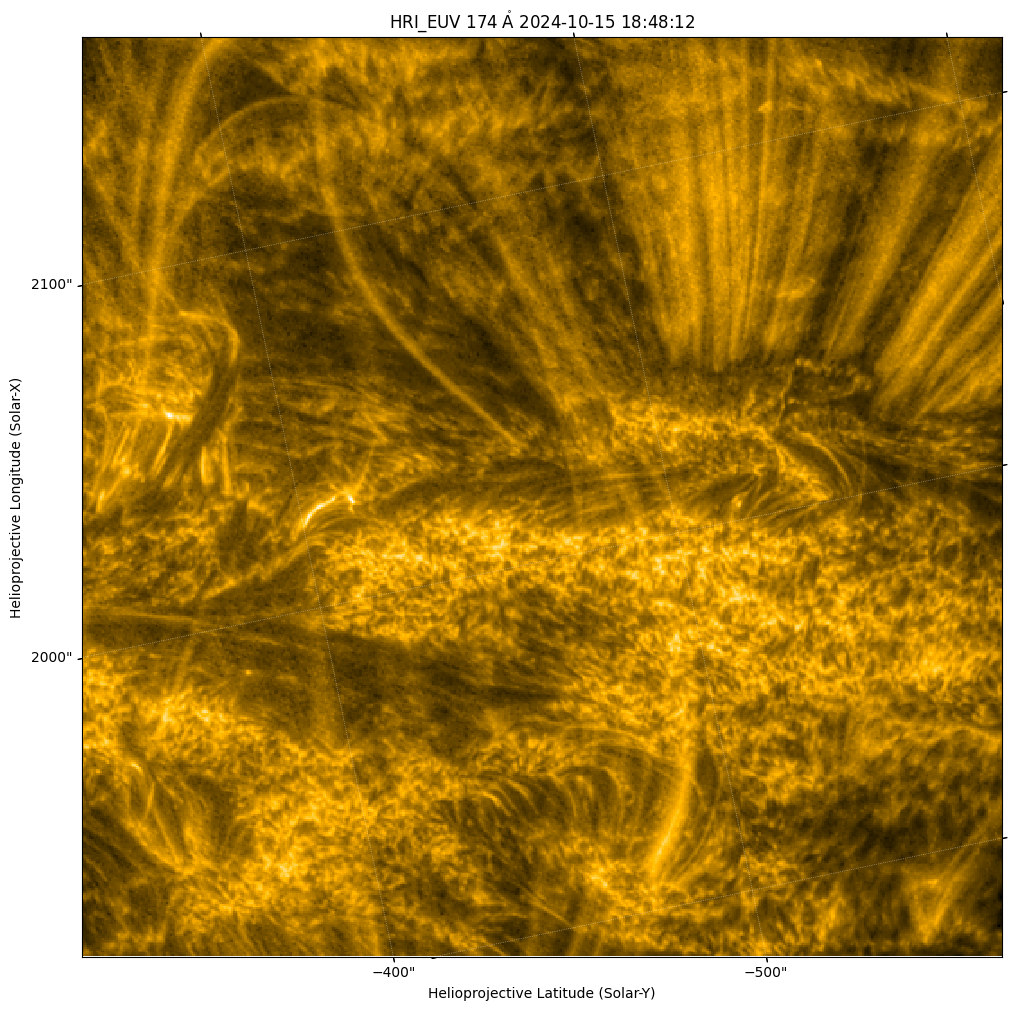

In [14]:
fig = plt.figure(figsize=(10,10), layout="constrained")
ax = fig.add_subplot(projection=test_map_boxcar_wow)
test_map_boxcar_wow.plot(norm=ImageNormalize(), axes=ax)

In [16]:
def make_movie(hri_maps_array_mean_boxcar, hri_maps, save_dir, save_map=False):
    map_0 = sunpy.map.Map(hri_maps_array_mean_boxcar[:,:,0], hri_maps[0].meta)
    map_0 = map_0.rotate(105*u.deg).submap(bottom_left=(256,256)*u.pix,
                                  top_right=(256+512+256-1, 256+512+256-1)*u.pix)
    map_0_wow = wow(map_0.submap(bottom_left=(256, 128)*u.pix,
                   top_right=(256+512-1, 128+512-1)*u.pix),
                   bilateral=1, denoise_coefficients=[5,3,1], gamma=3.2, h=0.95)    
    
    if save_map:
        map_0_wow.save("../../data/20241015/hri_crop_wow/hrieuv_20241015_wow_0000.fits", overwrite=True)

    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(projection=map_0_wow)
    im = map_0_wow.plot(norm=ImageNormalize(), axes=ax, interpolation="none", title=None)
    title = ax.set_title("HRIEUV {}".format(hri_maps[0].date.strftime("%Y-%m-%dT%H:%M:%S")),
    fontdict={'fontsize': 12, 'family': 'monospace'})

    plt.tight_layout()
    plt.show()
    
    def update_fig(ii, im, title):
        map_ = sunpy.map.Map(hri_maps_array_mean_boxcar[:,:,ii], hri_maps[ii].meta)
        map_ = map_.rotate(105*u.deg).submap(bottom_left=(256,256)*u.pix,
                                  top_right=(256+512+256-1, 256+512+256-1)*u.pix)
        map_wow = wow(map_.submap(bottom_left=(256, 128)*u.pix,
                   top_right=(256+512-1, 128+512-1)*u.pix),
                   bilateral=1, denoise_coefficients=[5,3,1], gamma=3.2, h=0.95)
        
        if save_map:
            map_wow.save("../../data/20241015/hri_crop_wow/hrieuv_20241015_wow_{:04d}.fits".format(ii), overwrite=True)
        im.set_data(map_wow.data)
        title.set_text("HRIEUV {}".format(hri_maps[ii].date.strftime("%Y-%m-%dT%H:%M:%S")))
        return ax
    
    anim = animation.FuncAnimation(fig, update_fig, fargs=(im, title),
                                   frames=hri_maps_array_mean_boxcar.shape[2], #range(10), #
                                   blit=False)
    
    anim.save(save_dir, fps=30, dpi=150,writer='ffmpeg', 
          codec='libx264',
          # bitrate=6000,
          extra_args=['-pix_fmt', 'yuv420p'])
    
    return anim

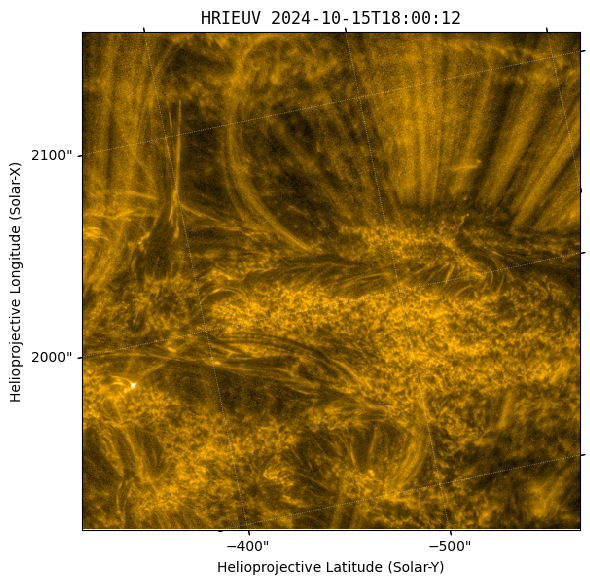

In [17]:
make_movie(hri_maps_array_mean_boxcar, hri_maps, "../../figs/test_movie/hrieuv_20241015_wow.mp4", save_map=True)